/tmp/ipykernel_4248/3708903102.py:121: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()


Generating synthetic data...
Starting training on XLA:0...


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Epoch [10/50], Loss: 1.146940
Epoch [20/50], Loss: 0.833141
Epoch [30/50], Loss: 0.734168
Epoch [40/50], Loss: 0.643497
Epoch [50/50], Loss: 0.590710
Training finished.
Running visualization on a test sample...
Plot saved to agent_simulation_output.png


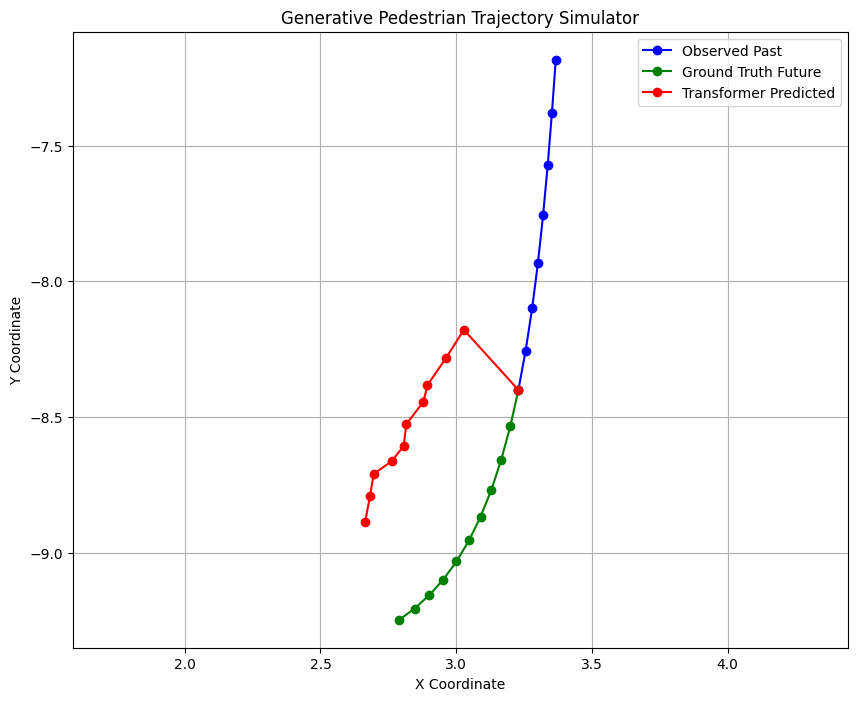

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# PyTorch/XLA imports
try:
    import torch_xla.core.xla_model as xm
    import torch_xla.distributed.parallel_loader as pl
    XLA_AVAILABLE = True
except ImportError:
    # Define a mock xm object for CPU execution
    class MockXm:
        def xla_device(self):
            return torch.device("cpu")
        def optimizer_step(self, optimizer, barrier=False):
            optimizer.step()
        def master_print(self, msg):
            print(msg)
    xm = MockXm()
    XLA_AVAILABLE = False

# --- 1. Synthetic Data Generation ---

def generate_synthetic_data(num_samples=100000, past_len=8, future_len=10):
    """
    Generates synthetic pedestrian trajectories.
    Each trajectory is a linear path with sinusoidal noise.
    """
    seq_len = past_len + future_len
    all_trajectories = []

    for _ in range(num_samples):
        # Random start point and velocity
        start_pos = np.random.rand(2) * 20 - 10
        velocity = np.random.randn(2) * 2.5

        # Linear base path
        time_steps = np.linspace(0, seq_len / 10.0, seq_len).reshape(-1, 1)
        base_path = start_pos + time_steps * velocity

        # Sinusoidal noise parameters
        freq = np.random.rand(2) * 2 + 0.5
        amp = np.random.rand(2) * 0.7 + 0.1
        phase = np.random.rand(2) * np.pi

        noise_x = amp[0] * np.sin(freq[0] * time_steps + phase[0])
        noise_y = amp[1] * np.cos(freq[1] * time_steps + phase[1])
        noise = np.hstack((noise_x, noise_y))

        trajectory = base_path + noise
        all_trajectories.append(trajectory)

    all_trajectories = np.array(all_trajectories, dtype=np.float32)
    
    observed_past = all_trajectories[:, :past_len, :]
    target_future = all_trajectories[:, past_len:, :]
    
    return torch.from_numpy(observed_past), torch.from_numpy(target_future)


# --- 2. Model Architecture ---

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=50):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class PedestrianTransformer(nn.Module):
    def __init__(self, input_dim=2, d_model=128, nhead=8, num_encoder_layers=4,
                 dim_feedforward=512, dropout=0.1, past_len=8, future_len=10):
        super(PedestrianTransformer, self).__init__()
        self.d_model = d_model
        self.past_len = past_len
        self.future_len = future_len
        self.input_dim = input_dim

        self.input_embedding = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout, max_len=past_len)
        
        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_encoder_layers)

        self.output_layer = nn.Linear(past_len * d_model, future_len * input_dim)

    def forward(self, src):
        # src shape: (batch_size, past_len, input_dim)
        embedded_src = self.input_embedding(src) * math.sqrt(self.d_model)
        pos_encoded_src = self.pos_encoder(embedded_src)
        
        encoder_output = self.transformer_encoder(pos_encoded_src)
        
        flat_output = encoder_output.reshape(encoder_output.size(0), -1)
        
        prediction = self.output_layer(flat_output)
        
        prediction = prediction.view(prediction.size(0), self.future_len, self.input_dim)
        
        return prediction

# --- 3. Training and Visualization ---

def train_and_visualize():
    """Main function for training and evaluation."""
    torch.manual_seed(42)
    device = xm.xla_device()

    # Hyperparameters
    PAST_LEN = 8
    FUTURE_LEN = 10
    EPOCHS = 50
    BATCH_SIZE = 512
    LEARNING_RATE = 1e-4
    
    # Data Loading
    xm.master_print("Generating synthetic data...")
    observed_past, target_future = generate_synthetic_data(num_samples=100000, past_len=PAST_LEN, future_len=FUTURE_LEN)

    split_idx = int(0.9 * len(observed_past))
    train_past, test_past = observed_past[:split_idx], observed_past[split_idx:]
    train_future, test_future = target_future[:split_idx], target_future[split_idx:]

    train_dataset = TensorDataset(train_past, train_future)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

    # Model, Loss, Optimizer
    model = PedestrianTransformer(
        past_len=PAST_LEN,
        future_len=FUTURE_LEN
    )
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Training Loop
    xm.master_print(f"Starting training on {str(device).upper()}...")
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        
        if XLA_AVAILABLE:
            para_loader = pl.ParallelLoader(train_loader, [device])
            train_iterator = para_loader.per_device_loader(device)
        else:
            train_iterator = train_loader

        for past_batch, future_batch in train_iterator:
            past_batch = past_batch.to(device)
            future_batch = future_batch.to(device)

            optimizer.zero_grad()
            predicted_future = model(past_batch)
            loss = criterion(predicted_future, future_batch)
            loss.backward()
            xm.optimizer_step(optimizer, barrier=True)
            running_loss += loss.item()

        avg_loss = running_loss / len(train_iterator)
        if (epoch + 1) % 10 == 0:
            xm.master_print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.6f}")

    xm.master_print("Training finished.")

    # Visualization
    xm.master_print("Running visualization on a test sample...")
    model.eval()
    
    with torch.no_grad():
        sample_past = test_past[42].unsqueeze(0).to(device)
        sample_future_true = test_future[42].unsqueeze(0)

        predicted_future = model(sample_past)

        past_coords = sample_past.cpu().numpy().squeeze(0)
        future_true_coords = sample_future_true.numpy().squeeze(0)
        future_pred_coords = predicted_future.cpu().numpy().squeeze(0)

    plt.figure(figsize=(10, 8))
    
    plt.plot(past_coords[:, 0], past_coords[:, 1], 'bo-', label='Observed Past')
    
    full_true_path = np.vstack([past_coords[-1], future_true_coords])
    plt.plot(full_true_path[:, 0], full_true_path[:, 1], 'go-', label='Ground Truth Future')
    
    full_pred_path = np.vstack([past_coords[-1], future_pred_coords])
    plt.plot(full_pred_path[:, 0], full_pred_path[:, 1], 'ro-', label='Transformer Predicted')
    
    plt.title('Generative Pedestrian Trajectory Simulator')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    
    output_filename = 'agent_simulation_output.png'
    plt.savefig(output_filename)
    xm.master_print(f"Plot saved to {output_filename}")

if __name__ == '__main__':
    train_and_visualize()